In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import *
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import cv2
import os

In [2]:
!pip install kaggle

In [3]:
!kaggle datasets download -d maitam/vietnamese-traffic-signs

Dataset URL: https://www.kaggle.com/datasets/maitam/vietnamese-traffic-signs
License(s): CC-BY-SA-4.0
100% 757M/757M [00:06<00:00, 118MB/s]



In [4]:
!unzip vietnamese-traffic-signs.zip

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
  inflating: archive/images/1435.jpg  
  inflating: archive/images/1436.jpg  
  inflating: archive/images/1437.jpg  
  inflating: archive/images/1438.jpg  
  inflating: archive/images/1439.jpg  
  inflating: archive/images/1440.jpg  
  inflating: archive/images/1441.jpg  
  inflating: archive/images/1442.jpg  
  inflating: archive/images/1443.jpg  
  inflating: archive/images/1444.jpg  
  inflating: archive/images/1445.jpg  
  inflating: archive/images/1446.jpg  
  inflating: archive/images/1447.jpg  
  inflating: archive/images/1448.jpg  
  inflating: archive/images/1449.jpg  
  inflating: archive/images/1450.jpg  
  inflating: archive/images/1451.jpg  
  inflating: archive/images/1452.jpg  
  inflating: archive/images/1453.jpg  
  inflating: archive/images/1454.jpg  
  inflating: archive/images/1455.jpg  
  inflating: archive/images/1456.jpg  
  inflating: archive/images/1457.jpg  
  inflating: archive/images/1458.jpg  
  infla

In [5]:
import os
import cv2
import numpy as np
from tqdm import tqdm

In [6]:
images=[]
labels=[]

In [7]:
img_dir="archive/images"
label_dir="archive/labels"

In [8]:
image_files=sorted(
    os.listdir(img_dir)
)

In [9]:
for img_name in tqdm(image_files):

    img_path=os.path.join(
        img_dir,
        img_name
    )

    label_path=os.path.join(
        label_dir,
        img_name.replace(".jpg",".txt")
    )

    if not os.path.exists(label_path):
        continue

    img=cv2.imread(img_path)

    if img is None:
        continue

    h,w,_=img.shape

    with open(label_path) as f:

        lines=f.readlines()

    for line in lines:

        cls,xc,yc,bw,bh=map(
            float,
            line.split()
        )

        x1=int((xc-bw/2)*w)
        y1=int((yc-bh/2)*h)

        x2=int((xc+bw/2)*w)
        y2=int((yc+bh/2)*h)

        crop=img[y1:y2,x1:x2]

        if crop.size==0:
            continue

        crop=cv2.resize(
            crop,
            (64,64)
        )

        images.append(crop)

        labels.append(int(cls))

100%|██████████| 3216/3216 [00:22<00:00, 142.32it/s]


In [10]:
X=np.array(images)

y=np.array(labels)

print(X.shape)

print(y.shape)

(8334, 64, 64, 3)
(8334,)


In [11]:
print(
    "number of classes:",
    len(np.unique(y))
)

number of classes: 52


In [12]:
print(
    np.unique(y)
)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51]


In [13]:
import matplotlib.pyplot as plt

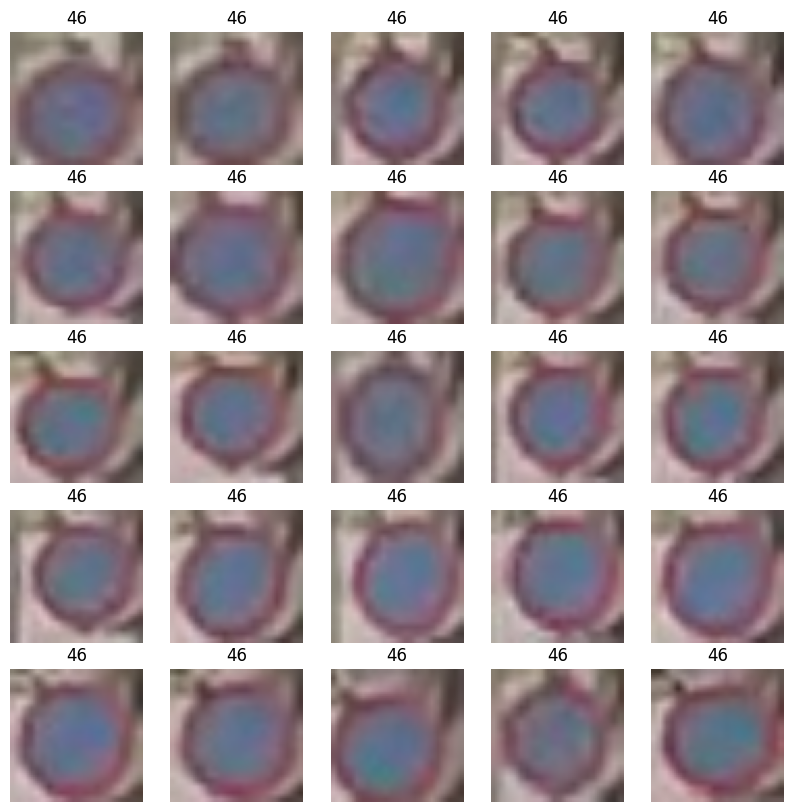

In [14]:
plt.figure(figsize=(10,10))

for i in range(25):

    plt.subplot(5,5,i+1)

    plt.imshow(
        cv2.cvtColor(
            X[i],
            cv2.COLOR_BGR2RGB
        )
    )

    plt.title(y[i])

    plt.axis("off")

plt.show()

In [15]:
X=X.astype(np.float32)/255.0

In [16]:
from tensorflow.keras.utils import to_categorical

In [17]:
num_classes=len(
    np.unique(y)
)

y_cat=to_categorical(
    y,
    num_classes
)

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X_train,\
X_test,\
y_train,\
y_test=train_test_split(

    X,
    y_cat,

    test_size=0.2,

    random_state=42,

    stratify=y
)

In [20]:
print(X_train.shape)

print(X_test.shape)

(6667, 64, 64, 3)
(1667, 64, 64, 3)


In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

In [22]:
cnn=Sequential([

    Conv2D(
        32,
        3,
        activation='relu',
        input_shape=(64,64,3)
    ),

    MaxPooling2D(),

    Conv2D(
        64,
        3,
        activation='relu'
    ),

    MaxPooling2D(),

    Conv2D(
        128,
        3,
        activation='relu'
    ),

    MaxPooling2D(),

    Flatten(),

    Dense(
        256,
        activation='relu'
    ),

    Dropout(0.3),

    Dense(
        num_classes,
        activation='softmax'
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
cnn.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [24]:
history_cnn=cnn.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=10,

    batch_size=64
)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - accuracy: 0.3446 - loss: 2.5275 - val_accuracy: 0.5510 - val_loss: 1.6273
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6329 - loss: 1.2693 - val_accuracy: 0.7751 - val_loss: 0.8606
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8016 - loss: 0.6934 - val_accuracy: 0.8351 - val_loss: 0.5953
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8672 - loss: 0.4505 - val_accuracy: 0.8966 - val_loss: 0.4307
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9002 - loss: 0.3118 - val_accuracy: 0.9205 - val_loss: 0.3882
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9242 - loss: 0.2560 - val_accuracy: 0.9183 - val_loss: 0.3860
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9415 - loss: 0.1938 - val_accuracy: 0.9093 - val_loss: 0.3714
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9494 - loss: 0.1648 - val_accuracy: 0.9385 - 

In [25]:
print(num_classes)
print(X.shape)

52
(8334, 64, 64, 3)


In [40]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint=ModelCheckpoint(
    "best_cnn.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

history_cnn=cnn.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[checkpoint],
    verbose=1
)

Epoch 1/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9604 - loss: 0.1227 - val_accuracy: 0.9408 - val_loss: 0.3406
Epoch 2/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9679 - loss: 0.0998 - val_accuracy: 0.9400 - val_loss: 0.3578
Epoch 3/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9747 - loss: 0.0790 - val_accuracy: 0.9453 - val_loss: 0.3860
Epoch 4/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9788 - loss: 0.0630 - val_accuracy: 0.9535 - val_loss: 0.3382
Epoch 5/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9816 - loss: 0.0626 - val_accuracy: 0.9618 - val_loss: 0.3529
Epoch 6/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9818 - loss: 0.0582 - val_accuracy: 0.9505 - val_loss: 0.4147
Epoch 7/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9829 - loss: 0.0576 - val_accuracy: 0.9565 - val_loss: 0.3603
Epoch 8/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9827 - loss: 0.0499 - val_accuracy: 0.

In [61]:
cnn.save("traffic_sign_cnn_model.keras")
print("Đã lưu mô hình CNN thành công.")

Đã lưu mô hình CNN thành công.


In [63]:
from sklearn.metrics import *

pred=cnn.predict(X_test)

pred=np.argmax(pred,axis=1)

true=np.argmax(y_test,axis=1)

acc=accuracy_score(true,pred)

prec=precision_score(
    true,
    pred,
    average='weighted'
)

rec=recall_score(
    true,
    pred,
    average='weighted'
)

f1=f1_score(
    true,
    pred,
    average='weighted'
)

print("Accuracy :",acc)
print("Precision:",prec)
print("Recall   :",rec)
print("F1-score :",f1)

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy : 0.9718056388722256
Precision: 0.973691011015563
Recall   : 0.9718056388722256
F1-score : 0.971582864810996


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


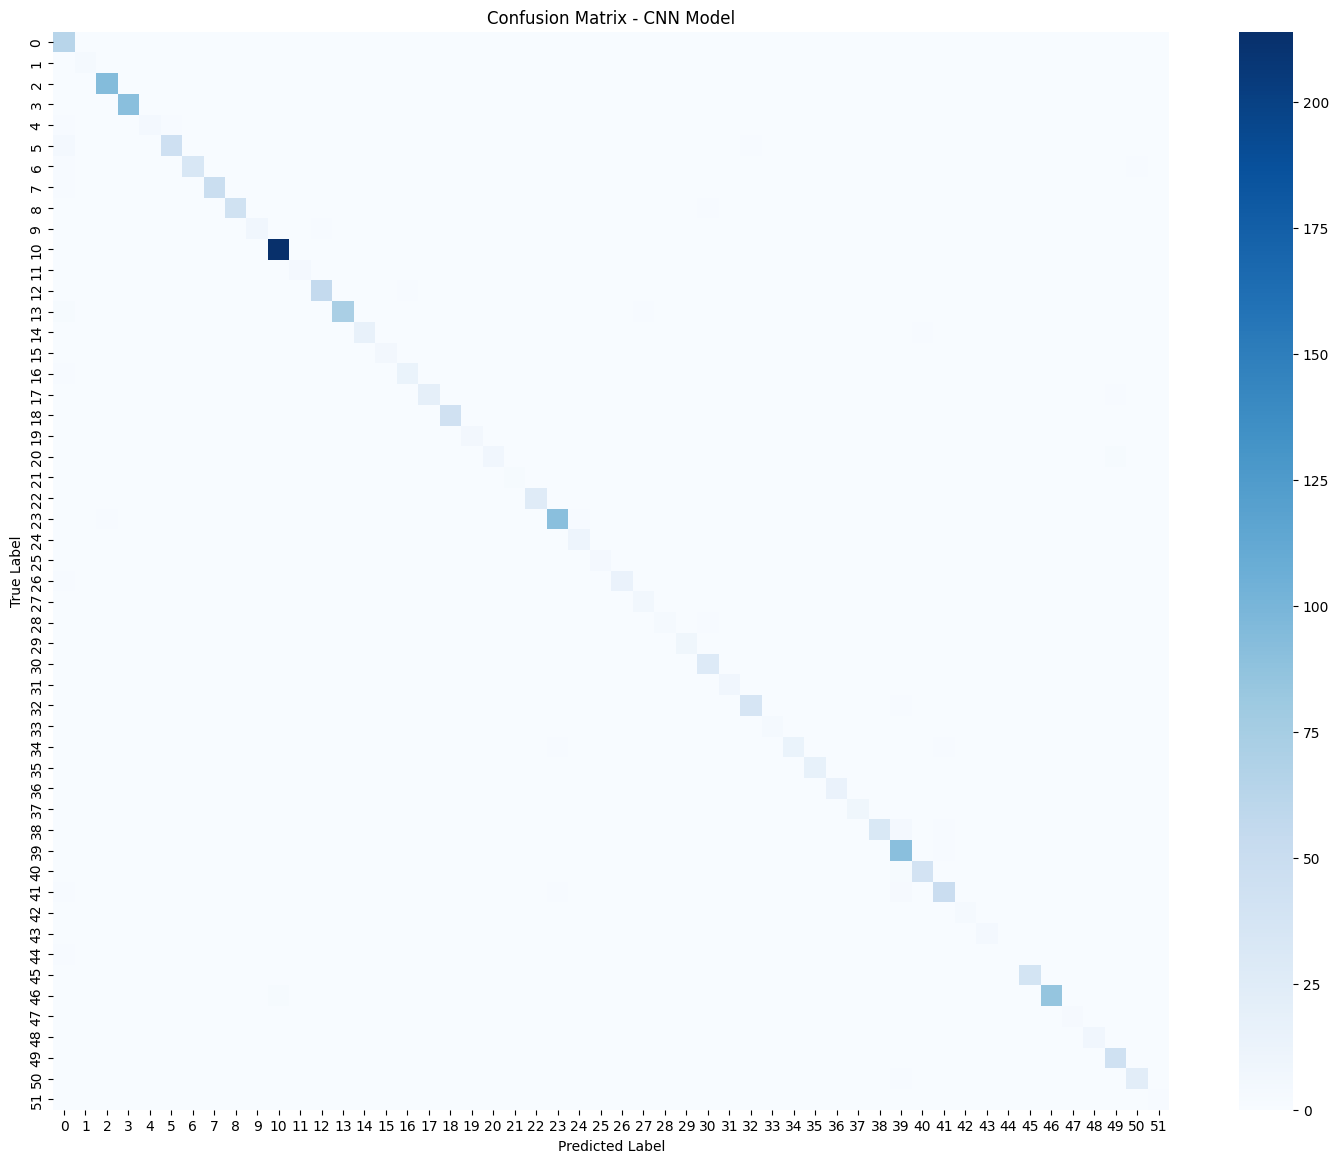

In [64]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true, pred)

plt.figure(figsize=(18, 14))
sns.heatmap(cm, cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - CNN Model")
plt.show()

In [65]:
from sklearn.metrics import classification_report

print(classification_report(true, pred, digits=4))

              precision    recall  f1-score   support

           0     0.8182    1.0000    0.9000        63
           1     1.0000    1.0000    1.0000         4
           2     0.9895    1.0000    0.9947        94
           3     1.0000    1.0000    1.0000        91
           4     1.0000    0.7143    0.8333         7
           5     0.9783    0.8824    0.9278        51
           6     1.0000    0.9444    0.9714        36
           7     1.0000    0.9800    0.9899        50
           8     1.0000    0.9767    0.9882        43
           9     1.0000    0.8889    0.9412         9
          10     0.9907    1.0000    0.9953       214
          11     1.0000    1.0000    1.0000         5
          12     0.9821    0.9821    0.9821        56
          13     1.0000    0.9600    0.9796        75
          14     1.0000    0.9412    0.9697        17
          15     1.0000    1.0000    1.0000         6
          16     0.9333    0.9333    0.9333        15
          17     1.0000    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


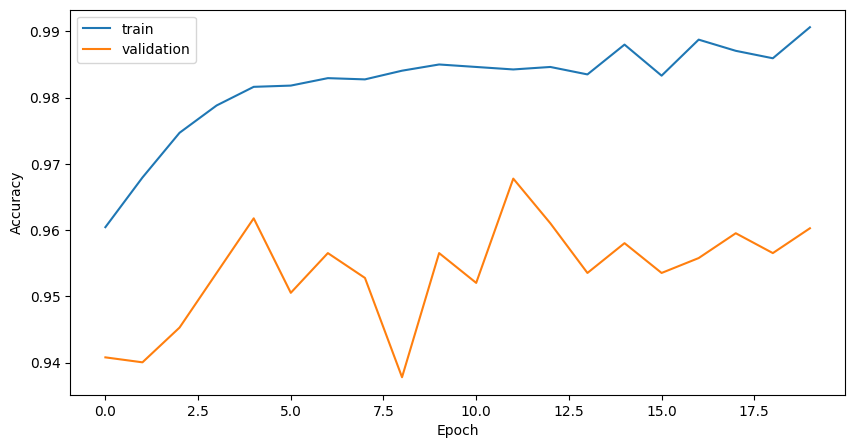

In [42]:
plt.figure(figsize=(10,5))

plt.plot(
    history_cnn.history['accuracy'],
    label='train'
)

plt.plot(
    history_cnn.history['val_accuracy'],
    label='validation'
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [43]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *

In [49]:
base_model=MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(64,64,3)
)

for layer in base_model.layers[:-20]:
    layer.trainable=False

for layer in base_model.layers[-20:]:
    layer.trainable=True

/tmp/ipykernel_721/2048602823.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model=MobileNetV2(


In [50]:
inp=Input(
    shape=(64,64,3)
)

x=base_model(inp)

x=GlobalAveragePooling2D()(x)

x=Dense(
    256,
    activation='relu'
)(x)

x=Dropout(0.3)(x)

out=Dense(
    num_classes,
    activation='softmax'
)(x)

mobilenet=Model(
    inp,
    out
)

In [51]:
mobilenet.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [52]:
history_mobile=mobilenet.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32
)

Epoch 1/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 34s 106ms/step - accuracy: 0.0898 - loss: 3.9998 - val_accuracy: 0.1544 - val_loss: 3.6230
Epoch 2/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.2698 - loss: 3.0046 - val_accuracy: 0.2294 - val_loss: 3.2461
Epoch 3/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.3880 - loss: 2.5054 - val_accuracy: 0.3306 - val_loss: 2.9201
Epoch 4/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4737 - loss: 2.1695 - val_accuracy: 0.4258 - val_loss: 2.5522
Epoch 5/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5260 - loss: 1.9164 - val_accuracy: 0.5000 - val_loss: 2.1755
Epoch 6/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5805 - loss: 1.6818 - val_accuracy: 0.5570 - val_loss: 1.8635
Epoch 7/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6160 - loss: 1.5371 - val_accuracy: 0.6109 - val_loss: 1.5919
Epoch 8/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6555 - loss: 1.3473 - val_acc

In [53]:
pred=mobilenet.predict(X_test)

pred=np.argmax(pred,axis=1)

true=np.argmax(y_test,axis=1)

acc_mobile=accuracy_score(
    true,
    pred
)

print(acc_mobile)

53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 80ms/step
0.8086382723455309


In [54]:
from tensorflow.keras.applications import ResNet50

In [36]:
base_model=ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(64,64,3)
)

base_model.trainable=False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [37]:
inp=Input(
    shape=(64,64,3)
)

x=base_model(inp)

x=GlobalAveragePooling2D()(x)

x=Dense(
    256,
    activation='relu'
)(x)

x=Dropout(0.3)(x)

out=Dense(
    num_classes,
    activation='softmax'
)(x)

resnet=Model(
    inp,
    out
)

In [38]:
resnet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [57]:
history_resnet=resnet.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    verbose=1
)

Epoch 1/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.2794 - loss: 2.7798 - val_accuracy: 0.3051 - val_loss: 2.6866
Epoch 2/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.3319 - loss: 2.5653 - val_accuracy: 0.3568 - val_loss: 2.4831
Epoch 3/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.3623 - loss: 2.3774 - val_accuracy: 0.3868 - val_loss: 2.3094
Epoch 4/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.3896 - loss: 2.2374 - val_accuracy: 0.4160 - val_loss: 2.1808
Epoch 5/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4135 - loss: 2.1216 - val_accuracy: 0.4610 - val_loss: 2.0855
Epoch 6/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4414 - loss: 2.0201 - val_accuracy: 0.4400 - val_loss: 2.0358
Epoch 7/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.4581 - loss: 1.9232 - val_accuracy: 0.4723 - val_loss: 1.8926
Epoch 8/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.4708 - loss: 1.8588 - val_accu

In [66]:
pred_resnet = resnet.predict(X_test)
pred_resnet = np.argmax(pred_resnet, axis=1)
true_resnet = np.argmax(y_test, axis=1)

acc_resnet = accuracy_score(true_resnet, pred_resnet)

print("ResNet50 Accuracy:", acc_resnet)

53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 115ms/step
ResNet50 Accuracy: 0.5746850629874025


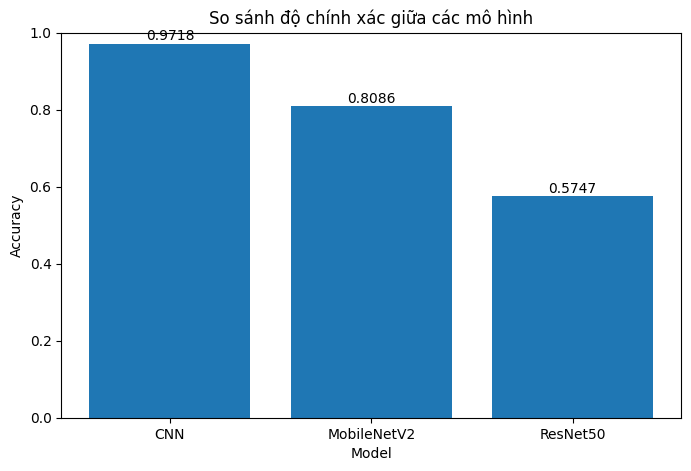

In [67]:
model_names = ["CNN", "MobileNetV2", "ResNet50"]
accuracies = [
    acc,
    acc_mobile,
    acc_resnet
]

plt.figure(figsize=(8, 5))
plt.bar(model_names, accuracies)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("So sánh độ chính xác giữa các mô hình")
plt.ylim(0, 1)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.4f}", ha="center")

plt.show()